In [2]:
from imcui.api.core import ImageMatchingAPI
import cv2
from imcui.ui.viz import display_matches
from imcui.ui.utils import wrap_images
import json
import numpy as np
import os

[2025/12/02 12:42:18 hloc WARNING] pycolmap is not installed, some features may not work.
[2025/12/02 12:42:20 hloc INFO] ARCSizeAwareModelCache initialized.


In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def viz(bgr, kpt_xys, kpt_names=None, radius=5, thickness=2, font_scale=0.5):
    """
    Visualize 2D keypoints on a BGR image using matplotlib.
    
    Parameters
    ----------
    bgr : np.ndarray
        OpenCV image in BGR format.
    kpt_xys : np.ndarray or list
        Array of shape (N, 2) containing (x, y) coordinates.
    kpt_names : list[str] or None
        Optional list of keypoint names, length N.
    radius : int
        Radius of each point.
    thickness : int
        Outline thickness for each point.
    font_scale : float
        Text label scale.
    """
    img = bgr.copy()
    kpt_xys = np.array(kpt_xys, dtype=np.float32)

    for i, (x, y) in enumerate(kpt_xys):
        name = str(kpt_names[i])
        if name.startswith('g_'):
            color = (0, 255, 0)
        else:
            color = (255, 0, 0)
        cv2.circle(img, (int(x), int(y)), radius, color, -1, cv2.LINE_AA)
        # cv2.circle(img, (int(x), int(y)), radius, (0, 0, 0), thickness, cv2.LINE_AA)
        if kpt_names is not None:
            if name.startswith('g_'):
                continue
            cv2.putText(
                img, name,
                (int(x) + 6, int(y) - 6),
                cv2.FONT_HERSHEY_SIMPLEX,
                font_scale, color, 1, cv2.LINE_AA
            )
            # cv2.putText(
            #     img, name,
            #     (int(x) + 6, int(y) - 6),
            #     cv2.FONT_HERSHEY_SIMPLEX,
            #     font_scale, (0, 0, 0), 2, cv2.LINE_AA
            # )

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [4]:
conf = {
    "ransac": {
        "enable": True,
        "estimator": "poselib",
        "geometry": "homography",
        "method": "cv2_USAC_MAGSAC",
        "reproj_threshold": 2,
        "confidence": 0.9999,
        "max_iter": 100000,
    },
    "matcher": {
        "output": "matches-minima_roma",
        "model": {
            "name": "roma",
            "weights": "outdoor",
            "model_name": "minima_roma.pth",
            "max_keypoints": 4000,
            "match_threshold": 0.2,
        },
        "preprocessing": {
            "grayscale": False,
            "force_resize": True,
            "resize_max": 1536,
            "width": 320,
            "height": 240,
            "dfactor": 8,
        },
    },
    "dense": True,
}

api = ImageMatchingAPI(conf=conf, device="cuda:0")
print(api.conf)

[2025/12/02 12:42:20 hloc INFO] Loading Roma model
[2025/12/02 12:42:26 hloc INFO] Load Roma model done.


Roma(
  (net): RegressionMatcher(
    (encoder): CNNandDinov2(
      (cnn): VGG19(
        (layers): ModuleList(
          (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU(inplace=True)
          (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (9): ReLU(inplace=True)
          (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_runni

In [5]:
model = api.matcher
model

Roma(
  (net): RegressionMatcher(
    (encoder): CNNandDinov2(
      (cnn): VGG19(
        (layers): ModuleList(
          (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU(inplace=True)
          (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (9): ReLU(inplace=True)
          (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_runni

In [6]:
preprocess_conf = api.match_conf["preprocessing"]
type(preprocess_conf), preprocess_conf

(dict,
 {'grayscale': False,
  'force_resize': True,
  'resize_max': 1536,
  'width': 320,
  'height': 240,
  'dfactor': 8})

In [7]:
with open('/home/dangnh36/datasets/ecg/processed/reference_keypoints.json', 'r') as f:
    ref_kpts = json.load(f)
ref_kpt_xys = np.array(list(ref_kpts.values()))
ref_kpt_names = list(ref_kpts.keys())
len(ref_kpt_names), ref_kpt_xys.shape

(2422, (2422, 2))

In [8]:
import argparse
import pprint
from collections import Counter, defaultdict
from itertools import chain
from pathlib import Path
from types import SimpleNamespace
from typing import Dict, Iterable, List, Optional, Set, Tuple, Union

import cv2
import h5py
import numpy as np
import torch
import torchvision.transforms.functional as F
from scipy.spatial import KDTree
from tqdm import tqdm

from imcui.hloc import logger, matchers
from imcui.hloc.extract_features import read_image, resize_image
from imcui.hloc.match_features import find_unique_new_pairs
from imcui.hloc.utils.base_model import dynamic_load
from imcui.hloc.utils.io import list_h5_names
from imcui.hloc.utils.parsers import names_to_pair, parse_retrieval

from imcui.hloc.configs import confs_dict

import torch
from PIL import Image

# confs = confs_dict["matchers"]

device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
IMG_DIR = '/home/dangnh36/datasets/ecg/raw/train/'

with open('/home/dangnh36/datasets/ecg/processed/imc_results.json', 'r') as f:
    imc_results = json.load(f)
len(imc_results)

977

In [10]:
from lightning import seed_everything
import pandas as pd

seed_everything(42)

INFO: Seed set to 42


INFO:lightning.fabric.utilities.seed:Seed set to 42


42

In [11]:
default_conf = {
    "grayscale": True,
    "resize_max": 1024,
    "dfactor": 8,
    "cache_images": False,
    "force_resize": False,
    "width": 320,
    "height": 240,
}

def preprocess(image: np.ndarray):
    image = image.astype(np.float32, copy=False)
    size = image.shape[:2][::-1]
    scale = np.array([1.0, 1.0])
    if conf.resize_max:
        scale = conf.resize_max / max(size)
        if scale < 1.0:
            size_new = tuple(int(round(x * scale)) for x in size)
            image = resize_image(image, size_new, "cv2_area")
            scale = np.array(size) / np.array(size_new)
    if conf.force_resize:
        size = image.shape[:2][::-1]
        image = resize_image(image, (conf.width, conf.height), "cv2_area")
        size_new = (conf.width, conf.height)
        scale = np.array(size) / np.array(size_new)
    if conf.grayscale:
        assert image.ndim == 2, image.shape
        image = image[None]
    else:
        image = image.transpose((2, 0, 1))  # HxWxC to CxHxW
    image = torch.from_numpy(image / 255.0).float()

    # assure that the size is divisible by dfactor
    size_new = tuple(
        map(
            lambda x: int(x // conf.dfactor * conf.dfactor),
            image.shape[-2:],
        )
    )
    image = F.resize(image, size=size_new)
    scale = np.array(size) / np.array(size_new)[::-1]
    return image, scale

conf = SimpleNamespace(**{**default_conf, **preprocess_conf})

def batch_perspective_transform_2d(src_pts, M):
    B, N, _ = src_pts.shape
    _src_pts = np.ones((B, N, 3), dtype=np.float32)
    _src_pts[..., :2] = src_pts
    # (B,3,3) @ (B,3,N) -> (B, N, 3)
    dst_pts = np.matmul(M, _src_pts.transpose(0, 2, 1)).transpose(0, 2, 1)
    dst_pts[..., :2] = dst_pts[..., :2] / dst_pts[..., 2:3]
    return dst_pts[..., :2]

In [12]:
by_homo_rows = []

for sid, sid_imc_result in tqdm(imc_results.items(), total = len(imc_results)):
    # ref_img_path = os.path.join(IMG_DIR, sid, f'{sid}-0001.png')
    # ref_img = cv2.cvtColor(cv2.imread(ref_img_path), cv2.COLOR_BGR2RGB)
    
    for type_id in [1, 3, 4, 5, 6, 9, 10, 11, 12]:
        if type_id == 1:
            new_row = [sid, type_id, None, None, {name: xy for name, xy in zip(ref_kpt_names, ref_kpt_xys.tolist())}]
            by_homo_rows.append(new_row)
            continue
        sid_imc_result = imc_results[sid]
        imc_result = sid_imc_result[str(type_id)]
        # print(sid, type_id, imc_result)
        H = np.array(imc_result[3])
        H_inv = np.linalg.pinv(H)
        rot_code = imc_result[1]

        # img_path = os.path.join(IMG_DIR, str(sid), f'{sid}-{int(type_id):04d}.png')
        # img = cv2.imread(img_path)
        # if rot_code is not None:
        #     img = cv2.rotate(img, rot_code)

        # xy
        dst_kpts = batch_perspective_transform_2d(ref_kpt_xys[None], H_inv)[0]
        # print(dst_kpts.shape)

        new_row = [sid, type_id, rot_code, H.tolist(), {name: xy for name, xy in zip(ref_kpt_names, dst_kpts.tolist())}]
        # print(len(new_row))
        by_homo_rows.append(new_row)
        
by_homo_df = pd.DataFrame(by_homo_rows, columns = ['id', 'type_id', 'rot_code', 'H', 'keypoints'])
by_homo_df

100%|███████████████████| 977/977 [00:12<00:00, 78.58it/s]


,id,type_id,rot_code,H,keypoints
0,1449491391,1,NaN,None,"{'g_0_1': [39.37007874015748, 7.08661417322832..."
1,1449491391,3,NaN,"[[1.0463203348119845, 0.0023429006764665626, -...","{'g_0_1': [69.90606551891375, 20.3304577008318..."
2,1449491391,4,NaN,"[[1.04500532394059, -0.00770514920676782, -22....","{'g_0_1': [59.58420366789311, 25.7660314749963..."
3,1449491391,5,NaN,"[[0.7972234573367881, 0.06865883835972961, -54...","{'g_0_1': [697.9222156315017, 409.055742136327..."
4,1449491391,6,NaN,"[[0.8146990605192405, 0.009941092709596498, -1...","{'g_0_1': [178.26900932087847, 1199.0988342755..."
...,...,...,...,...,...
8788,3817987033,6,NaN,"[[0.6944205329843228, 0.0427266598475784, -263...","{'g_0_1': [425.5261846035029, 178.976421356092..."
8789,3817987033,9,NaN,"[[0.6790596186459068, -0.002512575573528524, -...","{'g_0_1': [531.7365535671603, 291.058704940377..."
8790,3817987033,10,NaN,"[[0.5703740118479012, -0.0050616304256299255, ...","{'g_0_1': [202.12781819527848, 17.388749487535..."
8791,3817987033,11,NaN,"[[1.054806937395275, -0.007406002331329083, -2...","{'g_0_1': [59.76465691095734, 30.3960523484107..."


In [13]:
by_homo_df.to_csv('/home/dangnh36/datasets/ecg/processed/keypoints_by_homo.csv', index = False)

INFO: Seed set to 42


INFO:lightning.fabric.utilities.seed:Seed set to 42


  0%|                             | 0/977 [00:00<?, ?it/s]

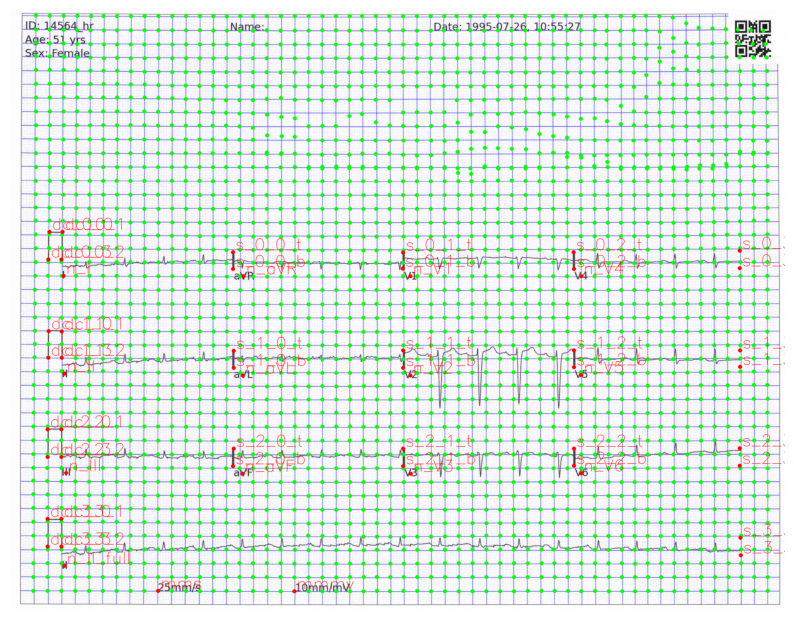

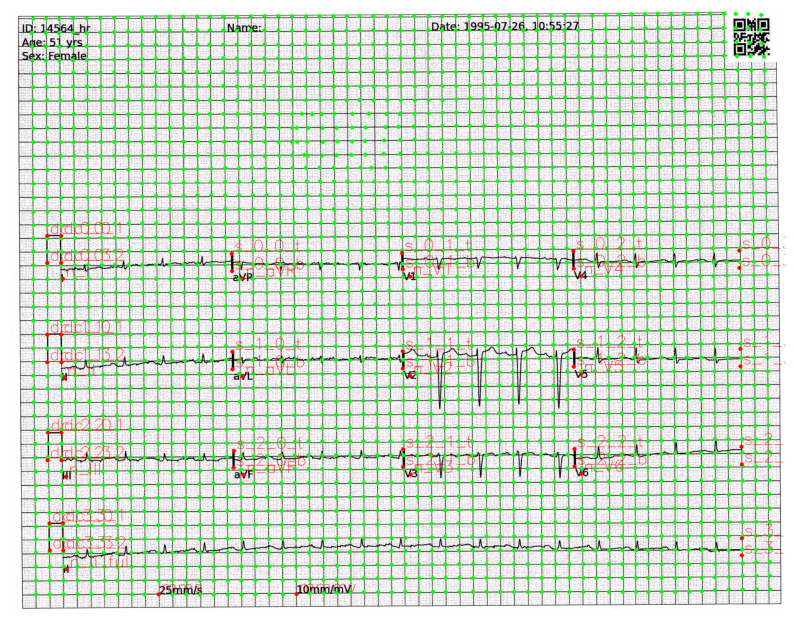

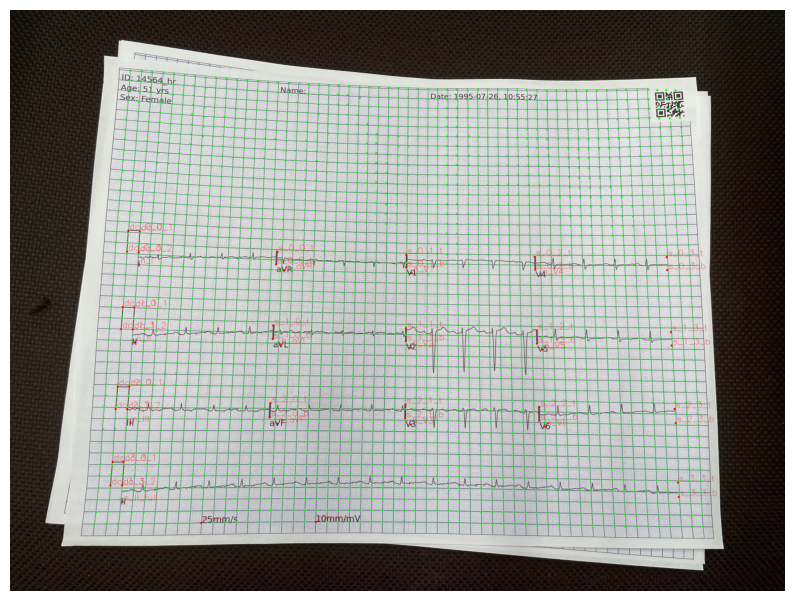

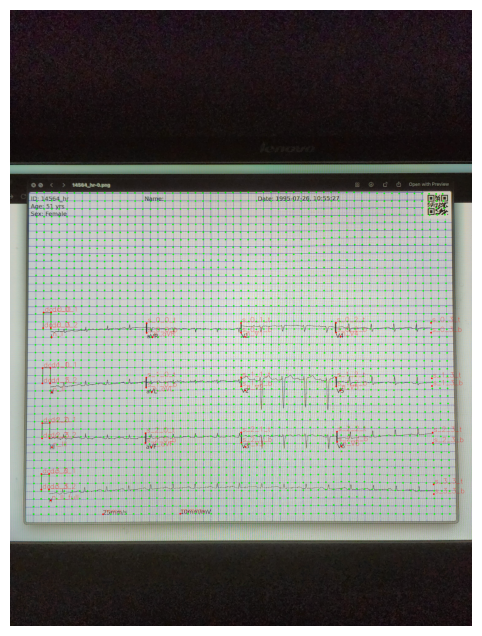

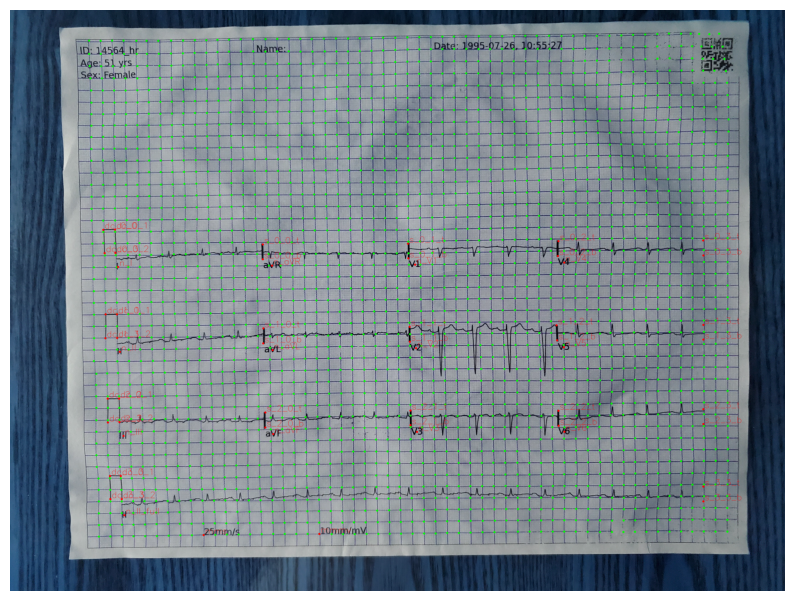

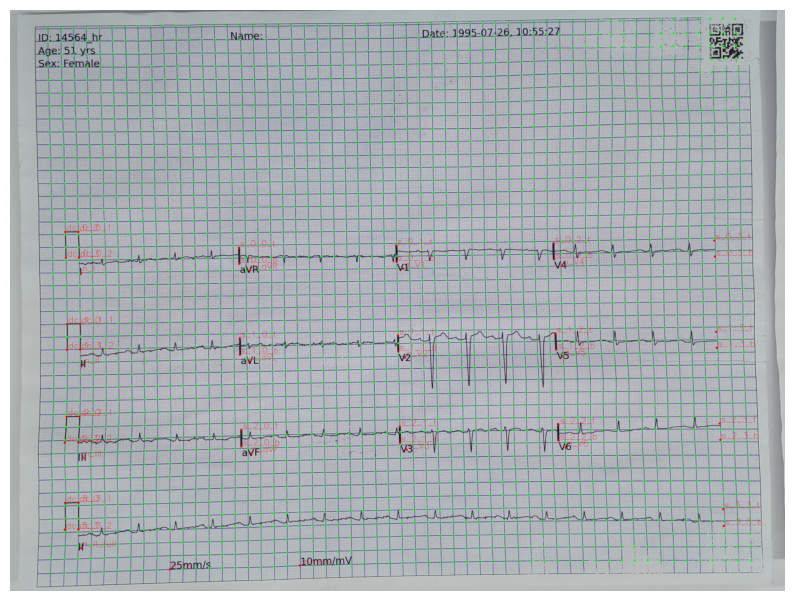

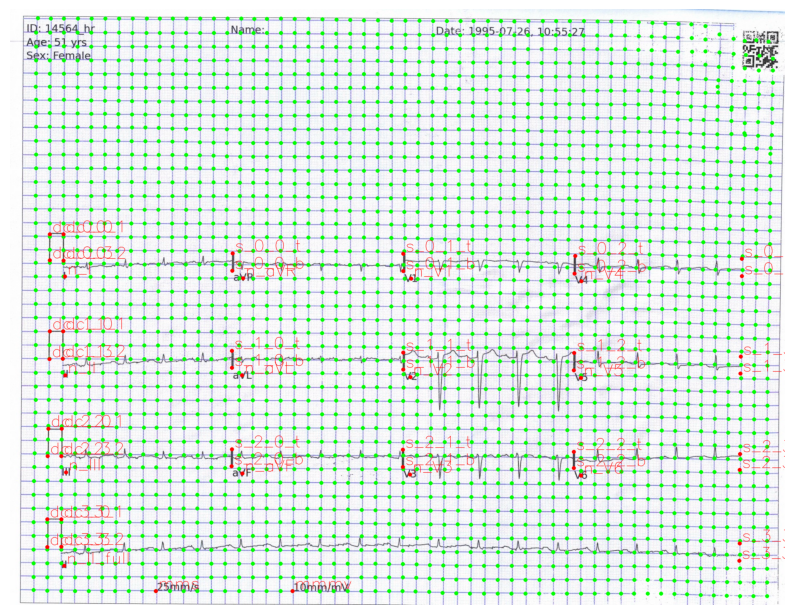

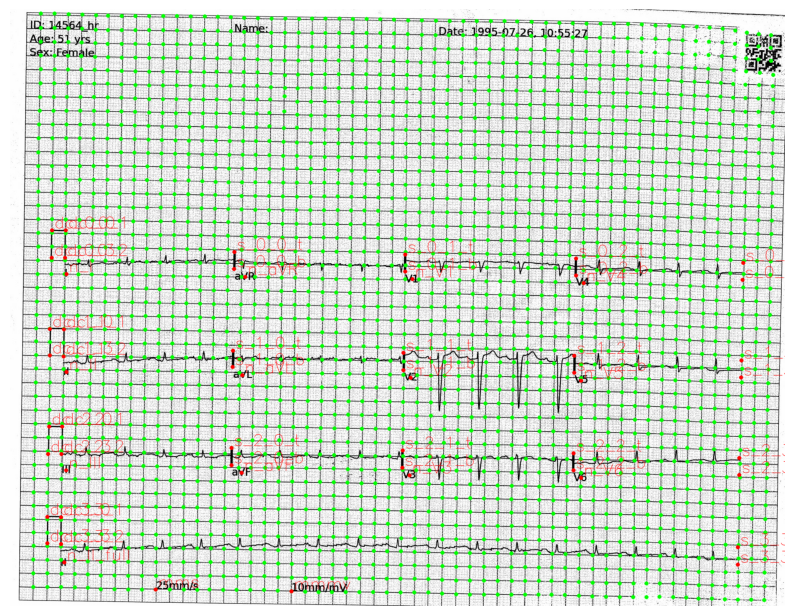

 65%|██████████▉      | 632/977 [1:40:41<40:54,  7.11s/it]

In [ ]:
seed_everything(42)

by_model_rows = []
for sid_idx, (sid, sid_imc_result) in tqdm(enumerate(imc_results.items()), total = len(imc_results)):
    ref_img_path = os.path.join(IMG_DIR, sid, f'{sid}-0001.png')
    ref_img = cv2.cvtColor(cv2.imread(ref_img_path), cv2.COLOR_BGR2RGB)
    
    for type_id in [1, 3, 4, 5, 6, 9, 10, 11, 12]:
        if type_id == 1:
            new_row = [sid, type_id, None, None, {name: xy for name, xy in zip(ref_kpt_names, ref_kpt_xys.tolist())}]
            by_model_rows.append(new_row)
            continue
        sid_imc_result = imc_results[sid]
        imc_result = sid_imc_result[str(type_id)]
        # print(sid, type_id, imc_result)
        H = np.array(imc_result[3])
        H_inv = np.linalg.pinv(H)
        rot_code = imc_result[1]

        img_path = os.path.join(IMG_DIR, str(sid), f'{sid}-{int(type_id):04d}.png')
        img = cv2.imread(img_path)
        if rot_code is not None:
            img = cv2.rotate(img, rot_code)

        image_0 = ref_img
        image_1 = img

        if len(image_0.shape) == 3 and conf.grayscale:
            image0 = cv2.cvtColor(image_0, cv2.COLOR_RGB2GRAY)
        else:
            image0 = image_0
        if len(image_0.shape) == 3 and conf.grayscale:
            image1 = cv2.cvtColor(image_1, cv2.COLOR_RGB2GRAY)
        else:
            image1 = image_1
        
        # comment following lines, image is always RGB mode
        # if not conf.grayscale and len(image0.shape) == 3:
        #     image0 = image0[:, :, ::-1]  # BGR to RGB
        # if not conf.grayscale and len(image1.shape) == 3:
        #     image1 = image1[:, :, ::-1]  # BGR to RGB
        
        image0, scale0 = preprocess(image0)
        image1, scale1 = preprocess(image1)
        image0 = image0.to(device)[None]
        image1 = image1.to(device)[None]
        data = {"image0": image0, "image1": image1}
        
        
        img0 = data["image0"].cpu().numpy().squeeze() * 255
        img1 = data["image1"].cpu().numpy().squeeze() * 255
        img0 = img0.transpose(1, 2, 0)
        img1 = img1.transpose(1, 2, 0)
        img0 = Image.fromarray(img0.astype("uint8"))
        img1 = Image.fromarray(img1.astype("uint8"))
        W_A, H_A = img0.size
        W_B, H_B = img1.size
        
        # Match
        warp, certainty = model.net.match(img0, img1, device=device)
        # print(warp.shape, certainty.shape)

        
        ref_h, ref_w = image_0.shape[:2]
        assert (ref_h, ref_w) == (1700, 2200)
        # grid_sample() accept xy in normalized space [-1, 1]
        x_A = ref_kpt_xys.copy()
        x_A[..., 0] = (x_A[..., 0] - ref_w / 2) / (ref_w / 2)
        x_A[..., 1] = (x_A[..., 1] - ref_h / 2) / (ref_h / 2)
        x_A = torch.from_numpy(x_A).float().cuda()

        x_B = torch.nn.functional.grid_sample(
            warp[:, :warp.shape[1] // 2, 2:].permute(2, 0, 1)[None],
            x_A[None, None],
            align_corners=False,
            mode="bilinear",
        )[0, :, 0].mT
        
        dst_h, dst_w = image_1.shape[:2]
        
        x_B = x_B.cpu().numpy()
        x_B[:, 0]  = dst_w / 2 * (x_B[:, 0] + 1)
        x_B[:, 1] = dst_h / 2 * (x_B[:, 1] + 1)

        dst_kpts = x_B

        if sid_idx == 0:
            viz(image_1.copy(), dst_kpts, kpt_names=ref_kpt_names, radius=5, thickness=2, font_scale=1.5)

        new_row = [sid, type_id, rot_code, H.tolist(), {name: xy for name, xy in zip(ref_kpt_names, dst_kpts.tolist())}]
        # print(len(new_row))
        by_model_rows.append(new_row)
        
by_model_df = pd.DataFrame(by_model_rows, columns = ['id', 'type_id', 'rot_code', 'H', 'keypoints'])
by_model_df

In [ ]:
by_model_df.to_csv('/home/dangnh36/datasets/ecg/processed/keypoints_by_model.csv', index = False)

In [18]:
by_model_df

,id,type_id,rot_code,H,keypoints
0,1449491391,1,NaN,None,"{'g_0_1': [39.37007874015748, 7.08661417322832..."
1,1449491391,3,NaN,"[[1.0463203348119845, 0.0023429006764665626, -...","{'g_0_1': [71.31941986083984, 17.0205402374267..."
2,1449491391,4,NaN,"[[1.04500532394059, -0.00770514920676782, -22....","{'g_0_1': [63.318851470947266, 26.166538238525..."
3,1449491391,5,NaN,"[[0.7972234573367881, 0.06865883835972961, -54...","{'g_0_1': [626.5728149414062, 320.081970214843..."
4,1449491391,6,NaN,"[[0.8146990605192405, 0.009941092709596498, -1...","{'g_0_1': [174.14447021484375, 1186.5632324218..."
...,...,...,...,...,...
8788,3817987033,6,NaN,"[[0.6944205329843228, 0.0427266598475784, -263...","{'g_0_1': [422.70196533203125, 173.43977355957..."
8789,3817987033,9,NaN,"[[0.6790596186459068, -0.002512575573528524, -...","{'g_0_1': [538.113037109375, 289.4401245117187..."
8790,3817987033,10,NaN,"[[0.5703740118479012, -0.0050616304256299255, ...","{'g_0_1': [198.09669494628906, 22.087604522705..."
8791,3817987033,11,NaN,"[[1.054806937395275, -0.007406002331329083, -2...","{'g_0_1': [63.45686340332031, 26.9091262817382..."


## Ensemble both methods

In [19]:
import polars as pl
from tqdm.notebook import tqdm

In [20]:
model_df = pl.read_csv('/home/dangnh36/datasets/ecg/processed/keypoints_by_model.csv')
model_df

id,type_id,rot_code,H,keypoints
i64,i64,f64,str,str
1449491391,1,null,null,"""{'g_0_1': [39.37007874015748, …"
1449491391,3,null,"""[[1.0463203348119845, 0.002342…","""{'g_0_1': [71.31941986083984, …"
1449491391,4,null,"""[[1.04500532394059, -0.0077051…","""{'g_0_1': [63.318851470947266,…"
1449491391,5,null,"""[[0.7972234573367881, 0.068658…","""{'g_0_1': [626.5728149414062, …"
1449491391,6,null,"""[[0.8146990605192405, 0.009941…","""{'g_0_1': [174.14447021484375,…"
…,…,…,…,…
3817987033,6,null,"""[[0.6944205329843228, 0.042726…","""{'g_0_1': [422.70196533203125,…"
3817987033,9,null,"""[[0.6790596186459068, -0.00251…","""{'g_0_1': [538.113037109375, 2…"
3817987033,10,null,"""[[0.5703740118479012, -0.00506…","""{'g_0_1': [198.09669494628906,…"


In [21]:
homo_df = pl.read_csv('/home/dangnh36/datasets/ecg/processed/keypoints_by_homo.csv')
homo_df

id,type_id,rot_code,H,keypoints
i64,i64,f64,str,str
1449491391,1,null,null,"""{'g_0_1': [39.37007874015748, …"
1449491391,3,null,"""[[1.0463203348119845, 0.002342…","""{'g_0_1': [69.90606551891375, …"
1449491391,4,null,"""[[1.04500532394059, -0.0077051…","""{'g_0_1': [59.58420366789311, …"
1449491391,5,null,"""[[0.7972234573367881, 0.068658…","""{'g_0_1': [697.9222156315017, …"
1449491391,6,null,"""[[0.8146990605192405, 0.009941…","""{'g_0_1': [178.26900932087847,…"
…,…,…,…,…
3817987033,6,null,"""[[0.6944205329843228, 0.042726…","""{'g_0_1': [425.5261846035029, …"
3817987033,9,null,"""[[0.6790596186459068, -0.00251…","""{'g_0_1': [531.7365535671603, …"
3817987033,10,null,"""[[0.5703740118479012, -0.00506…","""{'g_0_1': [202.12781819527848,…"


In [29]:
import numpy as np

def keypoint_match_mask(kpts_a, kpts_b, radius_threshold):
    """
    Compare two lists/arrays of keypoints (N, 2) in (x, y) format.
    They are assumed to be in the same order and length.

    Parameters
    ----------
    kpts_a : array-like, shape (N, 2)
    kpts_b : array-like, shape (N, 2)
    radius_threshold : float
        Distance threshold in pixels to consider a keypoint as matched.

    Returns
    -------
    match_mask : np.ndarray, shape (N,)
        Boolean mask, True where distance <= radius_threshold.
    matched_idx : np.ndarray
        Indices of matched keypoints.
    unmatched_idx : np.ndarray
        Indices of unmatched keypoints.
    """
    # Convert to numpy arrays
    kpts_a = np.asarray(kpts_a, dtype=float)
    kpts_b = np.asarray(kpts_b, dtype=float)

    if kpts_a.shape != kpts_b.shape:
        raise ValueError(f"Shape mismatch: {kpts_a.shape} vs {kpts_b.shape}")
    if kpts_a.ndim != 2 or kpts_a.shape[1] != 2:
        raise ValueError(f"Expected shape (N, 2), got {kpts_a.shape}")

    # Compute squared Euclidean distance per keypoint
    diff = kpts_a - kpts_b          # (N, 2)
    dist_sq = np.sum(diff ** 2, axis=1)  # (N,)

    # Threshold in squared space to avoid sqrt
    thr_sq = radius_threshold ** 2
    match_mask = dist_sq <= thr_sq  # (N,)

    # matched_idx = np.nonzero(match_mask)[0]
    # unmatched_idx = np.nonzero(~match_mask)[0]

    return match_mask, dist_sq

In [30]:
# ret_df = model_df.to_pandas()[['id', 'type_id', 'rot_code']]

all_homo_xys = []
all_model_xys = []
all_match_masks = []
all_dists = []
for i in tqdm(range(len(model_df))):
    model_row = model_df[i].to_dicts()[0]
    homo_row = homo_df[i].to_dicts()[0]

    assert model_row['id'] == homo_row['id']
    assert model_row['type_id'] == homo_row['type_id']
    assert model_row['rot_code'] == homo_row['rot_code']

    model_kpts = eval(model_row['keypoints'])
    homo_kpts = eval(homo_row['keypoints'])    
    model_xys = np.array(list(model_kpts.values()))
    homo_xys = np.array(list(homo_kpts.values()))

    all_model_xys.append(model_xys)
    all_homo_xys.append(homo_xys)

    # calculate suitable radius
    # first, calculate avg cell hw
    grid_xys = homo_xys[:43 * 55].reshape(43, 55, 2)
    cell_ws = (grid_xys[1:] - grid_xys[:-1])[..., 1]
    cell_hs = (grid_xys[:, 1:] - grid_xys[:, :-1])[..., 0]
    # print(cell_ws)
    # print(cell_hs)
    cell_w, cell_h = float(cell_ws.mean()), float(cell_hs.mean())
    cell_size = 0.5 * (cell_w + cell_h)
    if i < 10:
        print(cell_w, cell_h, cell_size)
    match_mask, dist_sq = keypoint_match_mask(model_xys, homo_xys, radius_threshold = 0.2 * cell_size)
    if i == 0:
        print(dist_sq)
    all_match_masks.append(match_mask)
    all_dists.append(dist_sq)
    err_rate = 1.0 - match_mask.sum() / len(match_mask)
    # if err_rate > 0.01:
    #     print('ERROR:', err_rate, model_row['id'], model_row['type_id'])

  0%|          | 0/8793 [00:00<?, ?it/s]

39.37007874015748 39.37007874015749 39.37007874015748
[0. 0. 0. ... 0. 0. 0.]
37.52998743651366 37.462088851517244 37.49603814401545
37.58400708065951 37.48106348790687 37.53253528428319
53.44284096589974 54.2162103764626 53.82952567118117
49.537719477604256 49.483977578182575 49.510848527893415
61.20700662780139 61.181717931378046 61.19436227958972
65.33565481018096 65.37287043719324 65.3542626236871
37.645276654124665 37.86603989368374 37.7556582739042
37.67100183153189 37.760008584571025 37.715505208051454
39.37007874015748 39.37007874015749 39.37007874015748


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x781a81088590>>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x781a81088590>>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x781a81088590>>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean

KeyboardInterrupt: 

In [24]:
all_match_masks = np.stack(all_match_masks, axis = 0)
all_dists = np.stack(all_dists, axis = 0)
all_match_masks.shape, all_dists.shape

((8793, 2422), (8793, 2422))

In [28]:
all_dists[0]

array([0., 0., 0., ..., 0., 0., 0.], shape=(2422,))

In [26]:
grid_dists = all_dists[:, :43 * 55].reshape(-1, 43, 55).mean(axis = 0)
grid_dists.shape

(43, 55)

In [27]:
grid_dists

array([[ 871.78788091,  758.29192724,  684.18659243, ...,  914.90473017,
        1171.39645739, 1530.86392623],
       [ 765.15341518,  653.53221321,  562.77715075, ...,  839.09819479,
        1048.4863836 , 1346.25490331],
       [ 688.74497294,  581.09992836,  494.11318293, ...,  788.78584975,
         956.65117528, 1165.62895013],
       ...,
       [ 545.45753087,  422.46355045,  349.57860913, ...,  197.65655113,
         237.48316302,  293.42300817],
       [ 609.66862742,  479.70965273,  399.37263184, ...,  221.08655229,
         262.72222494,  322.31525154],
       [ 678.21562308,  543.6226141 ,  459.8845976 , ...,  254.00711066,
         297.12117735,  360.79595747]], shape=(43, 55))